In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy

plt.style.use("ICIWstyle")

In [4]:
n_dot = np.load("MGA-E-11032025_120ml-min_1atm_ReactorInlet_MS_composition.npy")
timestamps = np.load("MGA-E-11032025_120ml-min_1atm_ReactorInlet_MS_times.npy")

In [5]:
time_delta = timestamps - timestamps[0]

np.savez(
    "MGA-E-11032025_120ml-min_1atm_ReactorInlet.npz", n_dot=n_dot, time_delta=time_delta
)


t_range = (time_delta.min(), time_delta.max())

In [6]:
t_offset = 7.5
t_halfperiod = 120

switching_times = np.full((20,), t_halfperiod)
switching_times = np.insert(switching_times, 0, t_offset)
switching_times = np.cumsum(switching_times)
print(switching_times)

intervals = [
    (switching_times[i], switching_times[i + 1])
    for i in range(len(switching_times) - 1)
]
print(intervals)

[   7  127  247  367  487  607  727  847  967 1087 1207 1327 1447 1567
 1687 1807 1927 2047 2167 2287 2407]
[(7, 127), (127, 247), (247, 367), (367, 487), (487, 607), (607, 727), (727, 847), (847, 967), (967, 1087), (1087, 1207), (1207, 1327), (1327, 1447), (1447, 1567), (1567, 1687), (1687, 1807), (1807, 1927), (1927, 2047), (2047, 2167), (2167, 2287), (2287, 2407)]


In [7]:
interp = scipy.interpolate.interp1d(
    time_delta,
    n_dot,
    kind="linear",
    fill_value="extrapolate",
)

In [8]:
t = np.linspace(*t_range, 1000)
n_dot_interp = interp(t)

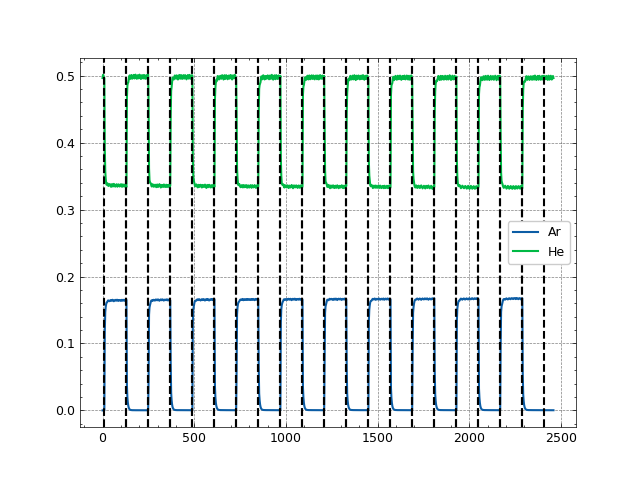

In [9]:
plt.plot(t, n_dot_interp[0], label="Ar")
plt.plot(t, n_dot_interp[1], label="He")
for interval in intervals:
    plt.axvline(interval[0], color="black", linestyle="--")
    plt.axvline(interval[1], color="black", linestyle="--")
plt.legend()

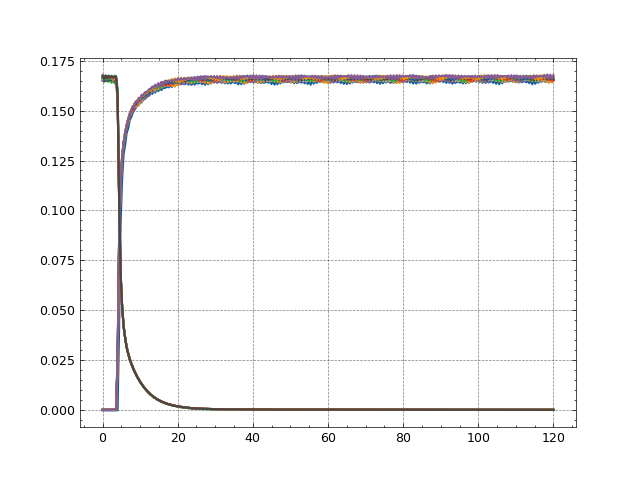

In [10]:
fig = plt.figure()
for interval in intervals:

    t = np.linspace(interval[0], interval[0] + t_halfperiod, 300)

    n_dot_interp = interp(t)

    plt.plot(t - interval[0], n_dot_interp[0])